# Classical

## Using IVP

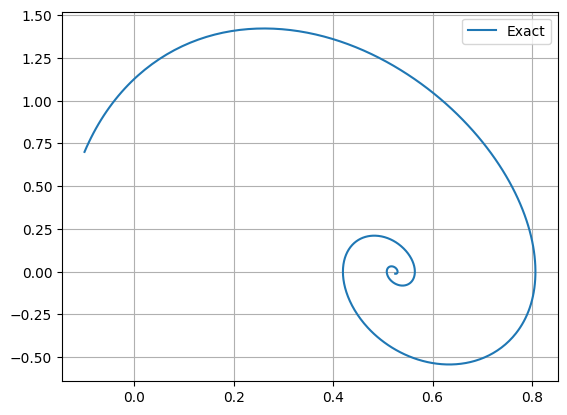

In [1]:
from scipy import linspace
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def SIMB(tspan, y):
    u1, u2 = y
    du1 = u2
    du2 = 5- 10*np.sin(u1)-1.7*u2
    return [du1, du2]

u0 = [-0.1, 0.7]
ts, te = 0, 6
t_exact = np.linspace(ts, te, 1000)
sol_exact = solve_ivp(SIMB, [ts, te], u0, t_eval=t_exact)

## PLOTTING
plt.plot(sol_exact.y[0], sol_exact.y[1], label='Exact')
plt.legend()
plt.grid()
# plt.savefig("x1x2_QADE-DWave.png") 
plt.show()

# DWave

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qade.bases import basis
from qade.equations import equation, ising, loss, solve
from qade.functions import function
from scipy.optimize import minimize

__all__ = ["basis", "equation", "ising", "loss", "solve", "function"]

t = np.linspace(0, 1, 100)  # Sample points at which the equation is to be evaluated
u1, u2, u3, u4, u5, u6, u7, u8, u9 = function(n_in=1, n_out=9)  # Functions to solve for Vande Pol using CarlemanLinearization

# Define the equations:
k1 = 3.8 - 0.2
Tscale = 4.1

eq1 = equation((u1[1] - (u2[0])*Tscale)/k1, t)
eq2 = equation((u2[1] - (5 - 10*u1[0] - 1.7*u2[0] + (5/3)*u6[0])*Tscale)/k1, t)
eq3 = equation((u3[1] - (2*u4[0])*Tscale)/k1, t)
eq4 = equation((u4[1] - (5*u1[0] - 10*u3[0] - 1.7*u4[0] + u5[0])*Tscale)/k1, t)
eq5 = equation((u5[1] - (10*u2[0] - 20*u4[0] - 3.4*u5[0])*Tscale)/k1, t)
eq6 = equation((u6[1] - (3*u7[0])*Tscale)/k1, t)
eq7 = equation((u7[1] - (5*u3[0] - 10*u6[0] - 1.7*u7[0] + 2*u8[0])*Tscale)/k1, t)
eq8 = equation((u8[1] - (10*u4[0] - 20*u7[0] - 3.4*u8[0] + u9[0])*Tscale)/k1, t)
eq9 = equation((u9[1] - (15*u5[0] - 30*u8[0] - 5.1*u9[0])*Tscale)/k1, t)

# Define initial conditions:
k2 = 2
k2a= 4 + 0.2
k2b= 2

a = -0.1
b = 0.7
ic1 = equation((u1[0] - a)*k2a, 0)
ic2 = equation((u2[0] - b)*k2a, 0)
ic3 = equation((u3[0] - a**2)*k2, 0)
ic4 = equation((u4[0] - a*b)*k2, 0)
ic5 = equation((u5[0] - b**2)*k2, 0)
ic6 = equation((u6[0] - a**3)*k2, 0)
ic7 = equation((u7[0] - (a**2)*b)*k2, 0)
ic8 = equation((u8[0] - a*(b**2))*k2, 0)
ic9 = equation((u9[0] - b**3)*k2, 0)


# Define Chebyshev basis
chebyshev_basis = basis("chebyshev", size_per_dim=20)

# Solve the system of equations with more reads and classical post-processing
y_sol = solve([eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8, eq9, ic1, ic2, ic3, ic3, ic4, ic5, ic6, ic7, ic8, ic9], 
                    chebyshev_basis, 
                    scales=1, 
                    num_reads=2000,  # Increased number of reads
                    n_epochs=20, 
                    n_spins=3, 
                    classical_minimizer=minimize)  # Enable classical post-processing


# Print results
print(f"loss = {y_sol.loss}, weights = {np.around(y_sol.weights, 2)}")

epoch = 0, loss = 8615.664428635597
epoch = 1, loss = 8971.954185364322
epoch = 2, loss = 11653.987113059542
epoch = 3, loss = 12157.152046749197
epoch = 4, loss = 11088.509793557361
epoch = 5, loss = 8007.981096985266
epoch = 6, loss = 12068.141198413776
epoch = 7, loss = 10465.222295285073
epoch = 8, loss = 6333.595541156058
epoch = 9, loss = 6011.633737130435
epoch = 10, loss = 13469.216753118144
epoch = 11, loss = 13210.149762909215
epoch = 12, loss = 5111.754296344752
epoch = 13, loss = 8478.357993275165
epoch = 14, loss = 9208.80420570291
epoch = 15, loss = 10092.979979072594
epoch = 16, loss = 8729.9997480441
epoch = 17, loss = 12162.532726089037
epoch = 18, loss = 6695.480409707814
epoch = 19, loss = 7492.777615977614
loss = 0.12950644578949522, weights = [[ 0.34 -0.17  1.07 -1.17  0.5  -0.06  0.28 -0.47 -0.12  0.97 -1.36  1.26
  -0.88  0.54 -0.53  0.65 -0.55  0.28 -0.08  0.01]
 [-0.93  0.9   0.69 -1.02 -0.39  1.6  -1.   -0.86  1.81 -0.83 -0.2   0.27
  -0.11 -0.21  0.79 -1.    

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


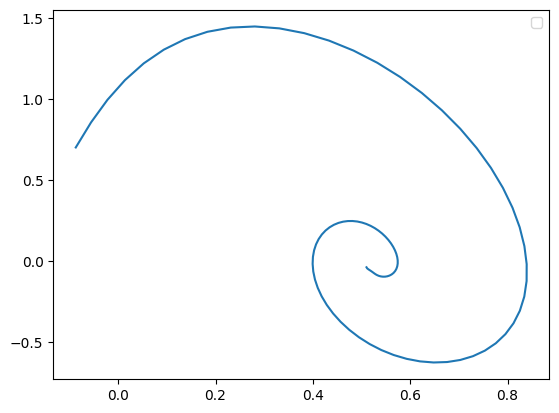

In [5]:
import matplotlib.pyplot as plt
import numpy as np

## Settings: Fourier 1

plt.plot(y_sol(t)[:, 0], y_sol(t)[:, 1])
plt.legend()
# plt.xlabel("$t$")
# plt.xlim((-5, 5))
# plt.ylim((-4, 4))
plt.show()
# y_sol(t)[:, 1]

## Exact Using IVP

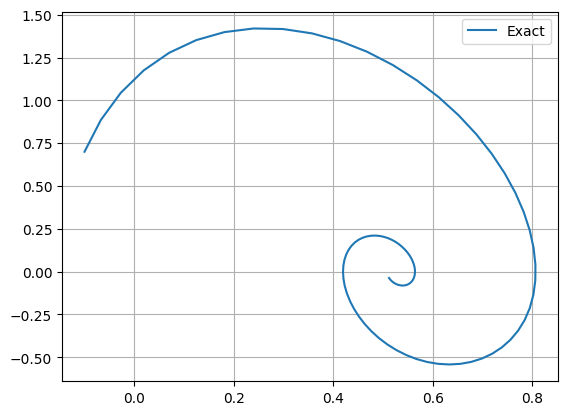

In [6]:
from scipy import linspace
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def SIMB(tspan, y):
    u1, u2 = y
    du1 = u2
    du2 = 5 - 10*np.sin(u1)-1.7*u2
    return [du1, du2]

# u0 = [-1.0,7.0]
# u0 = [-0.01, 0.07]
u0 = [a, b]

ts, te = 0, 4.1
t_exact = np.linspace(ts, te, 100)
sol_exact = solve_ivp(SIMB, [ts, te], u0, t_eval=t_exact)

## PLOTTING
plt.plot(sol_exact.y[0], sol_exact.y[1], label='Exact')
# plt.xlim([-2, 4])
# plt.ylim([-0.2, 0.4])
plt.legend()
plt.grid()
# plt.savefig("x1x2_QADE-DWave.png")
plt.show()

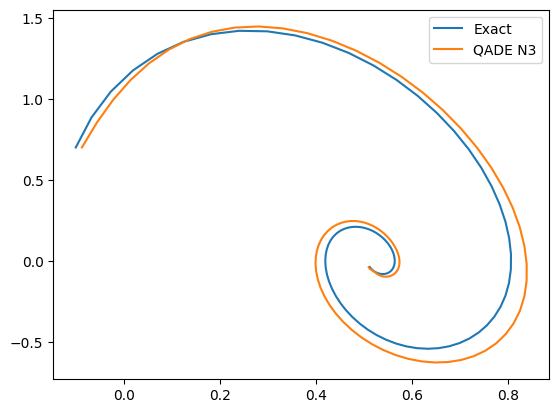

In [7]:
## Compare
plt.plot(sol_exact.y[0], sol_exact.y[1], label='Exact')
plt.plot(y_sol(t)[:, 0], y_sol(t)[:, 1], label='QADE N3')
plt.legend()

## CL Using IVP

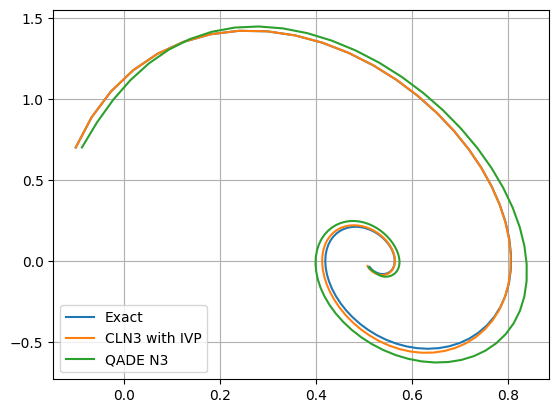

In [8]:
from scipy import linspace
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def SIMB_CLN3(tspan, y):
    u1, u2, u3, u4, u5, u6, u7, u8, u9 = y
    
    du1 = u2
    du2 = 5 - 10*u1 - 1.7*u2 + (5/3)*u6
    du3 = 2*u4 
    du4 = 5*u1 - 10*u3 -1.7*u4 + u5 
    du5 = 10*u2 - 20*u4 -3.4*u5
    du6 = 3*u7
    du7 = 5*u3 - 10*u6 - 1.7*u7 + 2*u8
    du8 = 10*u4 - 20*u7 - 3.4*u8 + u9
    du9 = 15*u5 - 30*u8 - 5.1*u9
    return [du1, du2, du3, du4, du5, du6, du7, du8, du9]

# a = -0.1
# b =  0.7
u0 = [a, b, a**2, a*b, b**2, a**3, (a**2)*b, a*(b**2), b**3]
ts, te = 0, 4.1
t_exact = np.linspace(ts, te, 100)
sol_CL_classical = solve_ivp(SIMB_CLN3, [ts, te], u0, t_eval=t_exact)

## PLOTTING
plt.plot(sol_exact.y[0], sol_exact.y[1], label='Exact')
plt.plot(sol_CL_classical.y[0], sol_CL_classical.y[1], label='CLN3 with IVP')
plt.plot(y_sol(t)[:, 0], y_sol(t)[:, 1], label='QADE N3')

# plt.xlim([-2, 4])
# plt.ylim([-0.2, 0.4])
plt.legend()
plt.grid()
plt.savefig("Customed_OnMachine-u1u2-Exact-CLN3-DWave.png")
plt.show()

In [9]:
u0

[-0.1,
 0.7,
 0.010000000000000002,
 -0.06999999999999999,
 0.48999999999999994,
 -0.0010000000000000002,
 0.007000000000000001,
 -0.048999999999999995,
 0.3429999999999999]

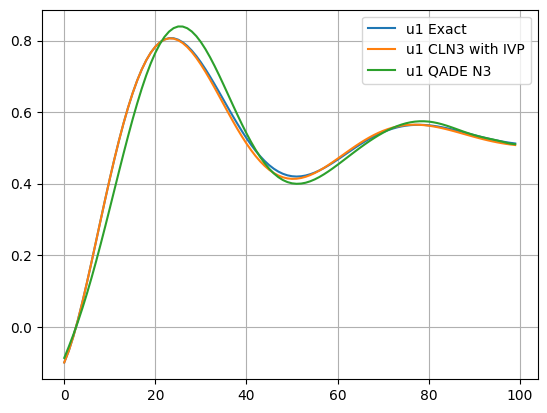

In [10]:
plt.plot(sol_exact.y[0], label='u1 Exact')
plt.plot(sol_CL_classical.y[0], label='u1 CLN3 with IVP')
plt.plot(y_sol(t)[:, 0], label='u1 QADE N3')
plt.legend()
plt.grid()
plt.savefig("Customed_OnMachine-u1vsu1-Exact-CLN3-DWave.png")
plt.show()
# sol_exact.y[0]

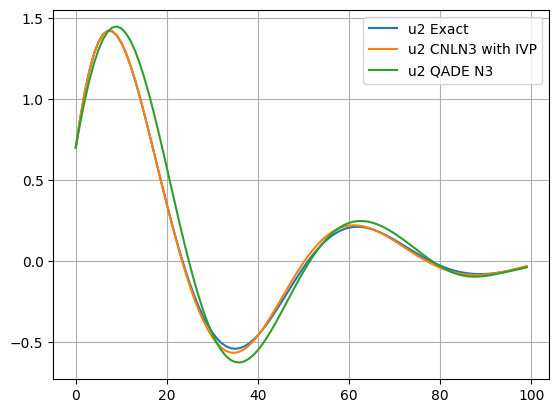

In [11]:
plt.plot(sol_exact.y[1], label='u2 Exact')
plt.plot(sol_CL_classical.y[1], label='u2 CNLN3 with IVP')
plt.plot(y_sol(t)[:, 1], label='u2 QADE N3')
plt.legend()
plt.grid()
plt.savefig("Customed_OnMachine-u2vsu2-Exact-CLN3-DWave.png")
plt.show()

In [13]:
column1QADE = y_sol(t)[:, 0]
column2QADE = y_sol(t)[:, 1]

import csv
file_path = 'OneMachine_CLN3-QADE.csv'

# Writing to CSV
with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['u1', 'u2'])  # Write header
    writer.writerows(zip(column1QADE, column2QADE))

In [14]:
column1Classical = sol_CL_classical.y[0]
column2Classical = sol_CL_classical.y[1]

import csv
file_path = 'OneMachine_CLN3-Classical.csv'

# Writing to CSV
with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['u1', 'u2'])  # Write header
    writer.writerows(zip(column1Classical, column2Classical))

In [15]:
column1Exact = sol_exact.y[0]
column2Exact = sol_exact.y[1]

import csv
file_path = 'OneMachine_CLN3-Exact.csv'

# Writing to CSV
with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['u1', 'u2'])  # Write header
    writer.writerows(zip(column1Exact, column2Exact))